# Linear Regression and Supervised Learning Exercises

This notebook contains all exercises for learning Linear Regression with Scikit-Learn.

## Table of Contents
- Exercise 0: Environment and Libraries
- Exercise 1: Scikit-learn Estimator
- Exercise 2: Linear Regression in 1D
- Exercise 3: Train Test Split
- Exercise 4: Forecast Diabetes Progression
- Exercise 5: Gradient Descent (Optional)

## Exercise 0: Environment and Libraries

First, let's verify that all required libraries are installed.

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.3.3


## Exercise 1: Scikit-learn Estimator

Fit a LinearRegression from Scikit-learn with X as features and y as target, then predict for x_pred = [[4]].

In [2]:
# Training data
X = [[1], [2.1], [3]]
y = [[1], [2], [3]]

# Initialize and fit the model
reg = LinearRegression()
reg.fit(X, y)

# Predict for x_pred = [[4]]
x_pred = [[4]]
prediction = reg.predict(x_pred)

# Print results
print(f"Prediction for {x_pred}: {prediction}")
print(f"Coefficients (coef_): {reg.coef_}")
print(f"Intercept (intercept_): {reg.intercept_}")
print(f"Score: {reg.score(X, y)}")

Prediction for [[4]]: [[3.96013289]]
Coefficients (coef_): [[0.99667774]]
Intercept (intercept_): [-0.02657807]
Score: 0.9966777408637874


## Exercise 2: Linear Regression in 1D

Generate 1D regression data, plot it, fit a model, and compute MSE for different noise levels.

In [3]:
def compute_mse(y_true, y_pred):
    """Compute Mean Squared Error"""
    return mean_squared_error(y_true, y_pred)

def run_experiment(noise_level):
    print(f"\n--- Running Experiment with Noise Level = {noise_level} ---")
    
    # 1. Generate data
    X, y, coef = make_regression(n_samples=100,
                                 n_features=1,
                                 n_informative=1,
                                 noise=noise_level,
                                 coef=True,
                                 random_state=0,
                                 bias=100.0)
    
    # 2. Plot the data
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', label='Data', alpha=0.6)
    plt.title(f'Linear Regression Data (Noise={noise_level})')
    plt.xlabel('X')
    plt.ylabel('y')
    
    # 3. Fit Linear Regression
    reg = LinearRegression()
    reg.fit(X, y)
    
    print(f"Model Equation: y = {reg.coef_[0]:.4f} * x + {reg.intercept_:.4f}")
    
    # 4. Add fitted line to plot
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_range_pred = reg.predict(x_range)
    
    plt.plot(x_range, y_range_pred, color='red', linewidth=2, label='Fitted Line')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 5. Predict on X
    y_pred = reg.predict(X)
    
    # 6. Compute MSE
    mse = compute_mse(y, y_pred)
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    
    return reg, mse


--- Running Experiment with Noise Level = 10 ---
Model Equation: y = 42.6194 * x + 99.1858


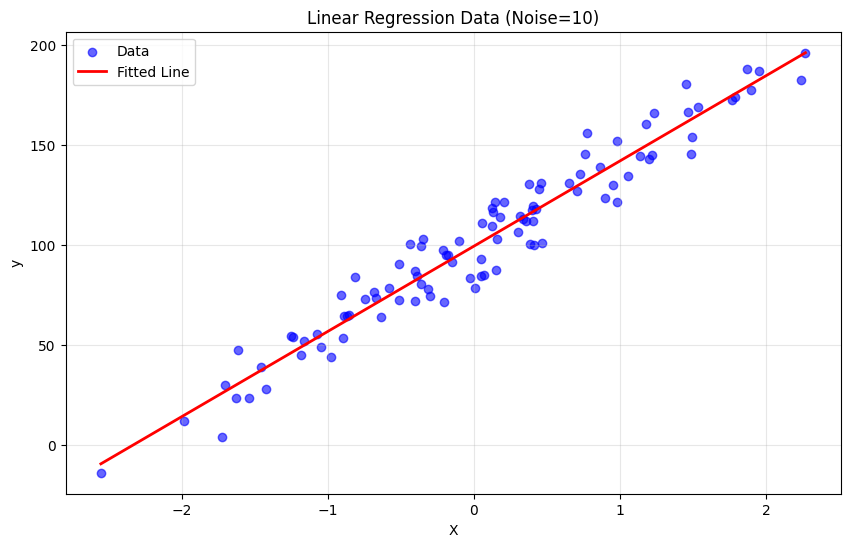

Mean Squared Error (MSE): 114.1715


In [4]:
# Run with noise=10
reg_10, mse_10 = run_experiment(noise_level=10)


--- Running Experiment with Noise Level = 50 ---
Model Equation: y = 43.5551 * x + 95.9291


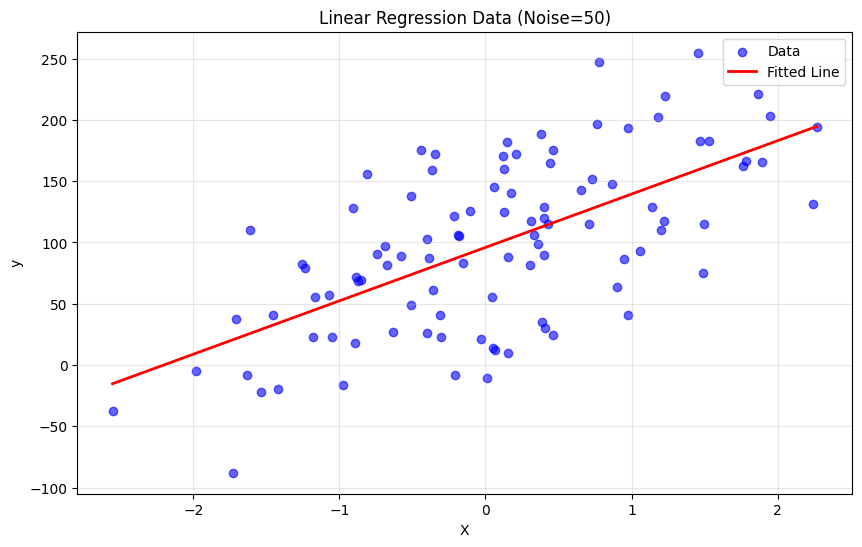

Mean Squared Error (MSE): 2854.2872


In [5]:
# Run with noise=50
reg_50, mse_50 = run_experiment(noise_level=50)

## Exercise 3: Train Test Split

Learn to split a dataset into training and testing sets.

In [6]:
# Create data
X = np.arange(1, 21).reshape(10, -1)
y = np.arange(1, 11)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Print results
print("\nX_train:\n", X_train)
print("\ny_train:\n", y_train)
print("\nX_test:\n", X_test)
print("\ny_test:\n", y_test)

Original X shape: (10, 2)
Original y shape: (10,)

X_train:
 [[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]
 [13 14]
 [15 16]]

y_train:
 [1 2 3 4 5 6 7 8]

X_test:
 [[17 18]
 [19 20]]

y_test:
 [ 9 10]


## Exercise 4: Forecast Diabetes Progression

Use Linear Regression to forecast diabetes progression using a real-world dataset.

In [7]:
# Load the dataset
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

print("Dataset shape:", X.shape)
print("Features:", X.columns.tolist())
print("\nFirst few rows:")
print(X.head())

Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First few rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

# Fit Linear Regression
reg = LinearRegression()
reg.fit(X_train, y_train)

# Coefficients and Intercept
print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

# Equation (simplified representation)
print("\nEquation: y = " + " + ".join([f"{c:.2f}*x{i}" for i, c in enumerate(reg.coef_)]) + f" + {reg.intercept_:.2f}")

Coefficients: [ -60.39984809 -226.08359044  529.38495719  259.96199412 -859.09300933
  504.68697339  157.41085788  226.29313436  840.7840406    34.71226556]
Intercept: 152.0532454782767

Equation: y = -60.40*x0 + -226.08*x1 + 529.38*x2 + 259.96*x3 + -859.09*x4 + 504.69*x5 + 157.41*x6 + 226.29*x7 + 840.78*x8 + 34.71*x9 + 152.05


In [9]:
# Predict on test set
y_pred = reg.predict(X_test)
print("Predictions on test set (first 5):", y_pred[:5])

# Compute MSE
mse_train = mean_squared_error(y_train, reg.predict(X_train))
mse_test = mean_squared_error(y_test, y_pred)

print(f"\nMSE on Train Set: {mse_train:.4f}")
print(f"MSE on Test Set: {mse_test:.4f}")

Predictions on test set (first 5): [111.74267934  98.41608992 168.36714629 255.06351455 168.44138847]

MSE on Train Set: 2888.3246
MSE on Test Set: 2858.2915


## Exercise 5: Gradient Descent (Optional)

Implement gradient descent from scratch and visualize the loss landscape.

In [10]:
# Generate data
X, y, coef = make_regression(n_samples=100,
                             n_features=1,
                             n_informative=1,
                             noise=10,
                             coef=True,
                             random_state=0,
                             bias=100.0)

def compute_mse(coefs, X, y):
    """
    coefs is a list that contains a and b: [a,b]
    X is the features set
    y is the target
    Returns a float which is the MSE
    """
    a, b = coefs
    y_preds = a * X.flatten() + b
    mse = np.mean((y_preds - y)**2)
    return mse

# Test MSE computation
print(f"MSE for a=1, b=2: {compute_mse([1, 2], X, y)}")

MSE for a=1, b=2: 11808.867339751561


In [11]:
# Create grid and compute losses
print("Computing losses for grid (this may take a moment)...")
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]

losses = []
for i in range(len(grid)):
    losses.append(compute_mse(grid[i], X, y))

losses_reshaped = np.array(losses).reshape(aa.shape)
print(f"Total grid points computed: {len(losses)}")

Computing losses for grid (this may take a moment)...
Total grid points computed: 640000


In [12]:
# Find optimal from grid
min_idx = np.argmin(losses)
optimal_a_grid = grid[min_idx][0]
optimal_b_grid = grid[min_idx][1]
print(f"Optimal a (grid): {optimal_a_grid}, Optimal b (grid): {optimal_b_grid}")

Optimal a (grid): 42.5, Optimal b (grid): 99.0


In [13]:
# Implement Gradient Descent
learning_rate = 0.1
n_iterations = 100
a = 0
b = 0
m = len(y)
history = []

print("Starting Gradient Descent...")
for i in range(n_iterations):
    y_pred = a * X.flatten() + b
    
    # Gradients
    d_a = (2/m) * np.sum((y_pred - y) * X.flatten())
    d_b = (2/m) * np.sum(y_pred - y)
    
    # Update
    a = a - learning_rate * d_a
    b = b - learning_rate * d_b
    
    history.append([a, b])

history = np.array(history)
print(f"Gradient Descent Optimal a: {a}, Optimal b: {b}")

Starting Gradient Descent...
Gradient Descent Optimal a: 42.61943031121357, Optimal b: 99.18581814447936


In [14]:
# Compare with Scikit-learn
reg = LinearRegression()
reg.fit(X, y)
print(f"Scikit-learn Optimal a: {reg.coef_[0]}, Optimal b: {reg.intercept_}")

Scikit-learn Optimal a: 42.61943029136694, Optimal b: 99.18581817296929


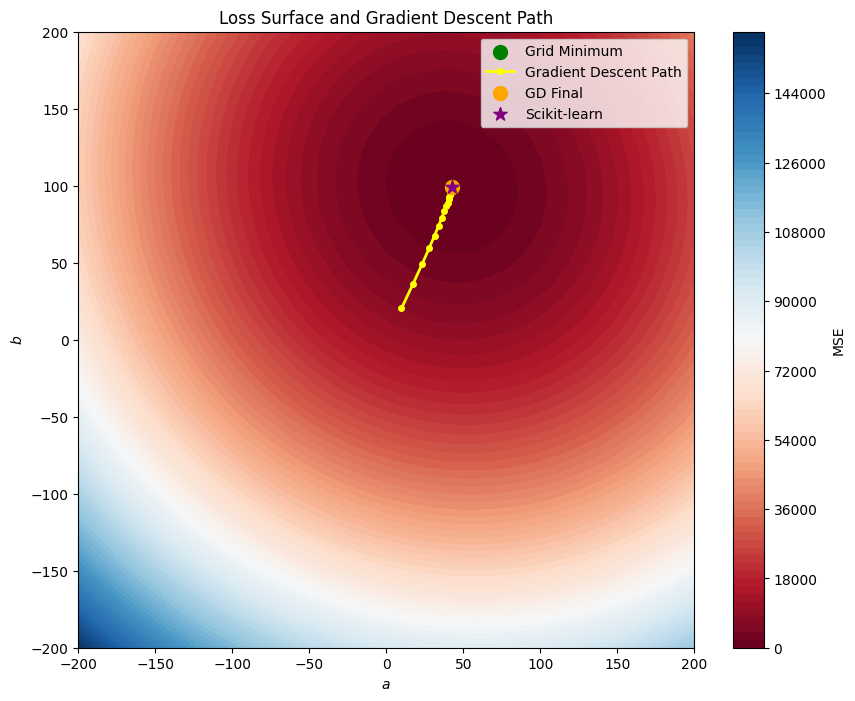


All three methods converged to approximately the same solution!


In [15]:
# Visualize the loss surface and gradient descent path
f, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(aa,
                    bb,
                    losses_reshaped,
                    100,
                    cmap="RdBu",
                    vmin=0,
                    vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.set(aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$")

# Plot grid minimum
ax.scatter(optimal_a_grid, optimal_b_grid, c='green', s=100, label='Grid Minimum', zorder=5)

# Plot gradient descent path
ax.plot(history[:, 0], history[:, 1], color='yellow', marker='.', 
        linestyle='-', label='Gradient Descent Path', linewidth=2, markersize=8, zorder=4)
ax.scatter(history[-1, 0], history[-1, 1], c='orange', s=100, label='GD Final', zorder=5)

# Plot Scikit-learn solution
ax.scatter(reg.coef_[0], reg.intercept_, c='purple', s=100, marker='*', 
          label='Scikit-learn', zorder=5)

plt.legend()
plt.title('Loss Surface and Gradient Descent Path')
plt.show()

print("\nAll three methods converged to approximately the same solution!")

## Summary

You have completed all Linear Regression exercises:

✅ Exercise 0: Environment setup and libraries  
✅ Exercise 1: Basic Scikit-learn estimator  
✅ Exercise 2: 1D Linear Regression with visualization  
✅ Exercise 3: Train-test split  
✅ Exercise 4: Real-world diabetes progression forecasting  
✅ Exercise 5: Manual gradient descent implementation  

Great work! 🎉